# 07. Model Classification: Selection - Pandas

## 07.1. Importação das bibliotecas

### 07.1.1. Importando as bibliotecas nativas do Python

In [1]:
import sys
from typing import Any

### 07.1.2. Importando as bibliotecas de terceiros

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

### 07.1.3. Importando os módulos locais do projeto

In [3]:
sys.path.append('..')
import functions.fn_charts_pandas as fn_charts_pandas
import functions.fn_stats_pandas as fn_stats_pandas
import params.consts as consts

## 07.2. Visão geral dos dados

### 07.2.1. Habilitando a exibição de todas as colunas

In [4]:
pd.set_option('display.max_columns', None)

### 07.2.2. Armazenando o dataset em uma variável

In [5]:
df = pd.read_parquet(consts.DATASET_CLUSTERED_PANDAS) 

### 07.2.3. Visualizando a quantidade de linhas e colunas do dataset

In [6]:
df.shape 

(2205, 23)

### 07.2.4. Exibindo o dataset

In [7]:
df.head(5) 

,Education,Marital_Status,Children,HasChildren,Age,AgeGroup,Income,Recency,Complain,Dt_Customer_Month,Dt_Customer_Quarter,Days_Since_Enrolled,Years_Since_Enrolled,NumDealsPurchases,NumWebVisitsMonth,NumTotalPurchases,MntRegularProds,MntGoldProds,MntTotal,AcceptedCmpTotal,HasAcceptedCmp,Response,Cluster
0,Graduation,Single,0,0,57,46-60,58138.0,58,0,9,3,663,1,3,7,22,1529,88,1617,0,0,1,2
1,Graduation,Single,2,1,60,46-60,46344.0,38,0,3,1,113,0,2,5,4,21,6,27,0,0,0,1
2,Graduation,Partner,0,0,49,46-60,71613.0,26,0,8,3,312,0,1,4,20,734,42,776,0,0,0,0
3,Graduation,Partner,1,1,30,18-30,26646.0,26,0,2,1,139,0,2,6,6,48,5,53,0,0,0,1
4,PhD,Partner,1,1,33,31-45,58293.0,94,0,1,1,161,0,5,5,14,407,15,422,0,0,0,2


### 07.2.5. Visualizando os detalhes do dataset

In [8]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Education             2205 non-null   object  
 1   Marital_Status        2205 non-null   object  
 2   Children              2205 non-null   int64   
 3   HasChildren           2205 non-null   int64   
 4   Age                   2205 non-null   int64   
 5   AgeGroup              2205 non-null   category
 6   Income                2205 non-null   float64 
 7   Recency               2205 non-null   int64   
 8   Complain              2205 non-null   int64   
 9   Dt_Customer_Month     2205 non-null   int64   
 10  Dt_Customer_Quarter   2205 non-null   int64   
 11  Days_Since_Enrolled   2205 non-null   int64   
 12  Years_Since_Enrolled  2205 non-null   int64   
 13  NumDealsPurchases     2205 non-null   int64   
 14  NumWebVisitsMonth     2205 non-null   int64   
 15  NumT

### 07.2.6. Visualizando as estatísticas das colunas numéricas

In [9]:
fn_stats_pandas.describe(df)

,Children,HasChildren,Age,Income,Recency,Complain,Dt_Customer_Month,Dt_Customer_Quarter,Days_Since_Enrolled,Years_Since_Enrolled,NumDealsPurchases,NumWebVisitsMonth,NumTotalPurchases,MntRegularProds,MntGoldProds,MntTotal,AcceptedCmpTotal,HasAcceptedCmp,Response,Cluster
count,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00
mean,0.95,0.72,45.10,51622.09,49.01,0.01,6.47,2.48,353.72,0.48,2.32,5.34,12.57,562.76,44.06,606.82,0.30,0.21,0.15,1.09
std,0.75,0.45,11.71,20713.06,28.93,0.09,3.49,1.14,202.56,0.50,1.89,2.41,7.18,575.94,51.74,601.68,0.68,0.41,0.36,0.76
min,0.00,0.00,18.00,1730.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,4.00,0.00,5.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,37.00,35196.00,24.00,0.00,3.00,1.00,180.00,0.00,1.00,3.00,6.00,56.00,9.00,69.00,0.00,0.00,0.00,1.00
50%,1.00,1.00,44.00,51287.00,49.00,0.00,6.00,2.00,356.00,0.00,2.00,6.00,12.00,343.00,25.00,397.00,0.00,0.00,0.00,1.00
75%,1.00,1.00,55.00,68281.00,74.00,0.00,10.00,4.00,529.00,1.00,3.00,7.00,18.00,964.00,56.00,1047.00,0.00,0.00,0.00,2.00
max,3.00,1.00,74.00,113734.00,99.00,1.00,12.00,4.00,699.00,1.00,15.00,20.00,32.00,2491.00,321.00,2525.00,4.00,1.00,1.00,2.00


### 07.2.7. Visualizando as estatísticas da colunas categóricas

In [10]:
df.describe(exclude = 'number') 

,Education,Marital_Status,AgeGroup
count,2205,2205,2205
unique,5,2,4
top,Graduation,Partner,31-45
freq,1113,1422,958


### 07.2.8. Verificando as colunas com valores nulos

In [11]:
df.isnull().sum() 

Education               0
Marital_Status          0
Children                0
HasChildren             0
Age                     0
AgeGroup                0
Income                  0
Recency                 0
Complain                0
Dt_Customer_Month       0
Dt_Customer_Quarter     0
Days_Since_Enrolled     0
Years_Since_Enrolled    0
NumDealsPurchases       0
NumWebVisitsMonth       0
NumTotalPurchases       0
MntRegularProds         0
MntGoldProds            0
MntTotal                0
AcceptedCmpTotal        0
HasAcceptedCmp          0
Response                0
Cluster                 0
dtype: int64

## 07.3. Treinamento dos modelos de classificação

### 07.3.1. Definindo os valores de X e y

In [12]:
X = df.drop('Response', axis = 1) 

X.head(5) 

,Education,Marital_Status,Children,HasChildren,Age,AgeGroup,Income,Recency,Complain,Dt_Customer_Month,Dt_Customer_Quarter,Days_Since_Enrolled,Years_Since_Enrolled,NumDealsPurchases,NumWebVisitsMonth,NumTotalPurchases,MntRegularProds,MntGoldProds,MntTotal,AcceptedCmpTotal,HasAcceptedCmp,Cluster
0,Graduation,Single,0,0,57,46-60,58138.0,58,0,9,3,663,1,3,7,22,1529,88,1617,0,0,2
1,Graduation,Single,2,1,60,46-60,46344.0,38,0,3,1,113,0,2,5,4,21,6,27,0,0,1
2,Graduation,Partner,0,0,49,46-60,71613.0,26,0,8,3,312,0,1,4,20,734,42,776,0,0,0
3,Graduation,Partner,1,1,30,18-30,26646.0,26,0,2,1,139,0,2,6,6,48,5,53,0,0,1
4,PhD,Partner,1,1,33,31-45,58293.0,94,0,1,1,161,0,5,5,14,407,15,422,0,0,2


In [13]:
y = df['Response'] 

y.head(5) 

0    1
1    0
2    0
3    0
4    0
Name: Response, dtype: int64

### 07.3.2. Listando as colunas numéricas e categóricas

In [14]:
numerical_features = X.select_dtypes(include = 'number').columns 

print('Numerical Features:') 

for i in numerical_features:

    print(f'- {i}')

Numerical Features:
- Children
- HasChildren
- Age
- Income
- Recency
- Complain
- Dt_Customer_Month
- Dt_Customer_Quarter
- Days_Since_Enrolled
- Years_Since_Enrolled
- NumDealsPurchases
- NumWebVisitsMonth
- NumTotalPurchases
- MntRegularProds
- MntGoldProds
- MntTotal
- AcceptedCmpTotal
- HasAcceptedCmp
- Cluster


In [15]:
categorical_features = X.select_dtypes(exclude = 'number').columns 

print('\nCategorical Features:') 

for i in categorical_features:
    
    print(f'- {i}')


Categorical Features:
- Education
- Marital_Status
- AgeGroup


### 07.3.3. Criando histogramas para entender a distribuição de dados das colunas

- Gráfico: Histograma.


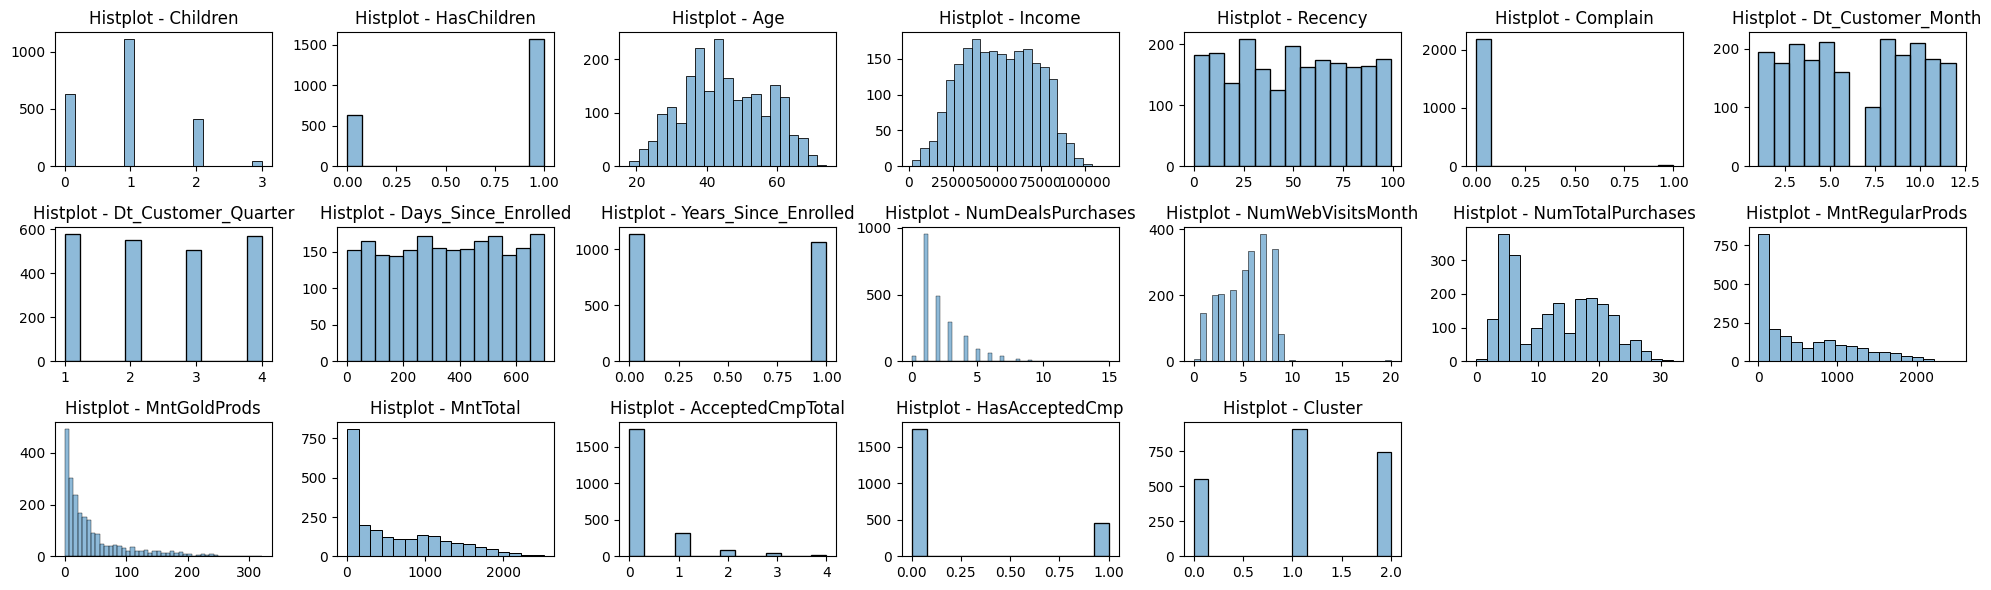

In [16]:
print('- Gráfico: Histograma.')

fn_charts_pandas.histplot(X, numerical_features, num_cols = 7, height_figsize = 2)

plt.savefig(f'../images/outputs/charts/pandas/nb07_histplot.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 07.3.4. Definindo o pré processamento das colunas de acordo com a distribuição dos seus dados

- **One Hot Encoder:** Indicado para colunas categóricas ou que possuem inteiros discretos.
- **Standard Scaler:** Indicado para colunas com distribuição semelhante à normal.
- **Power Transformer:** Indicado para colunas com assimetria dos dados.
- **Min-Max Scaler:** Indicado para colunas com distribuição uniforme dos dados.

In [17]:
one_hot_encoder_columns = [
    'Education',
    'Marital_Status',
    'AgeGroup',
    'Children',
    'HasChildren',
    'Complain',
    'Years_Since_Enrolled',
    'AcceptedCmpTotal',
    'HasAcceptedCmp',
    'Cluster',
]

standard_scaler_columns = [
    'Income',
    'Age',
]

power_transformer_columns = [
   'NumDealsPurchases',
   'NumWebVisitsMonth',
   'NumTotalPurchases',
   'MntRegularProds',
   'MntGoldProds',
   'MntTotal',
]

min_max_scaler_columns = [
    'Recency',
    'Dt_Customer_Month',
    'Dt_Customer_Quarter',
    'Days_Since_Enrolled',
]

### 07.3.5. Criando uma função com o pipeline para treinar os modelos

In [18]:
def pipeline(X: pd.DataFrame, y: pd.Series, model: BaseEstimator) -> dict[str, Any]: 
    """
    Função que executa todo o fluxo de machine learning: pré-processamento, seleção de features,
    balanceamento de classes, treinamento do modelo e validação cruzada.

    Args:
        X (pd.DataFrame): Valores de X.
        y (pd.Series): Variável alvo.
        model (BaseEstimator): Modelo de machine learning.

    Returns:
        dict: Dicionário com as métricas dos treinamentos.
    """

    pre_processing = ColumnTransformer(

        [

            ('one_hot_encoder', OneHotEncoder(), one_hot_encoder_columns),

            ('standard_scaler', StandardScaler(), standard_scaler_columns),

            ('power_transformer', PowerTransformer(), power_transformer_columns),

            ('min_max_scaler', MinMaxScaler(), min_max_scaler_columns)

        ]

    )

    pipeline = Pipeline(

        [

            ('pre_processing', pre_processing), 

            ('feature_selection', SelectKBest(score_func = f_classif, k = 10)), 

            ('resampling', RandomUnderSampler(random_state = consts.RANDOM_STATE)), 

            ('model', model), 

        ]

    )

    scores = cross_validate(
        
        pipeline, 

        X, 

        y, 

        cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = consts.RANDOM_STATE), 

        scoring = ['accuracy', 'precision', 'recall', 'roc_auc', 'average_precision'], 

        n_jobs = -2, 

    )

    return scores 

### 07.3.6. Treinando os modelos e armazenando suas métricas

In [19]:
scores = {

    'DummyClassifier': pipeline(X, y, DummyClassifier(strategy = 'stratified', random_state = consts.RANDOM_STATE)),

    'DecisionTreeClassifier': pipeline(X, y, DecisionTreeClassifier(random_state = consts.RANDOM_STATE)),

    'LogisticRegression': pipeline(X, y, LogisticRegression(random_state = consts.RANDOM_STATE)),

    'KNNClassifier': pipeline(X, y, KNeighborsClassifier(n_neighbors = 5)),

    'SVC': pipeline(X, y, SVC(random_state = consts.RANDOM_STATE)),

    'ExtraTreesClassifier': pipeline(X, y, ExtraTreesClassifier(random_state = consts.RANDOM_STATE)),

    'RandomForestClassifier': pipeline(X, y, RandomForestClassifier(random_state = consts.RANDOM_STATE)),

    'AdaBoostClassifier': pipeline(X, y, AdaBoostClassifier(random_state = consts.RANDOM_STATE)),

    'XGBClassifier': pipeline(X, y, XGBClassifier(random_state = consts.RANDOM_STATE)),

}

### 07.3.7. Evitando overfitting dos modelos

- **Feature Selection:** No aspecto de Feature Selection, foi aplicado o SelectKBest para selecionar as melhores features (colunas) para a criação do modelo, de modo que estivessem somente as features mais relevantes para o modelo e que não houvesse dados redundantes.
- **Balanceamento de Classes:** No aspecto de Balanceamento de Classes, como o dataset do projeto é desbalanceado, foi aplicado a técnica de Random Under Sampling (RUS) para se equiparar os valores da classe target ("Response"), onde se reduz a quantidade de valores da classe majoritária até que fique igual aos valores da classe minoritária.
- **Validação Cruzada:** No aspecto de Validação Cruzada, foi aplicado o Stratified K-Fold, por ser um dataset desbalanceado, para dividir o conjunto de treinamento em várias partes (folds) e realizar o treinamento e validação do modelo em combinações diferentes desses folds, de modo que se obtém resultados mais confiáveis das métricas de avaliação do modelo e reduz o viés associado a uma única divisão do conjunto de treinamento.
- **Regularização:** No aspecto de Regularização, foi aplicado a regularização L2 (Ridge) para adicionar uma penalidade ao modelo com base no coeficientes dos parâmetros, de modo que os coeficientes se tornem muito grandes e assim reduzindo o overfitting.

## 07.4. Seleção do modelo de classificação

### 07.4.1. Criando um dataset com as métricas dos treinamentos dos modelos

In [20]:
pd.set_option('display.max_rows', None)

for k, v in scores.items(): 

    scores[k]['time'] = scores[k]['fit_time'] + scores[k]['score_time'] 

df_metrics = pd.DataFrame(scores).T.reset_index().rename(columns = {'index': 'model'}) 

df_metrics = df_metrics.explode(df_metrics.columns[1:].to_list()).reset_index(drop = True) 

df_metrics = df_metrics.rename(columns = lambda c: c.replace('test_', ''))

df_metrics = df_metrics.drop(columns = ['fit_time', 'score_time'])

df_metrics

,model,accuracy,precision,recall,roc_auc,average_precision,time
0,DummyClassifier,0.512472,0.154206,0.492537,0.50429,0.15305,0.057117
1,DummyClassifier,0.503401,0.14486,0.462687,0.486691,0.148657,0.070801
2,DummyClassifier,0.503401,0.14486,0.462687,0.486691,0.148657,0.053879
3,DummyClassifier,0.487528,0.126168,0.409091,0.455212,0.14005,0.074161
4,DummyClassifier,0.510204,0.149533,0.484848,0.499758,0.149598,0.046013
5,DecisionTreeClassifier,0.693878,0.276316,0.626866,0.667551,0.232212,0.060071
6,DecisionTreeClassifier,0.659864,0.235669,0.552239,0.624631,0.200868,0.06741
7,DecisionTreeClassifier,0.680272,0.279762,0.701493,0.679543,0.242778,0.066049
8,DecisionTreeClassifier,0.639456,0.21118,0.515152,0.58503,0.178887,0.066442
9,DecisionTreeClassifier,0.70068,0.301205,0.757576,0.724121,0.264467,0.086805


### 07.4.2. Criando diagramas de caixa para comparar as métricas dos modelos

- Gráfico: Diagrama de Caixa.


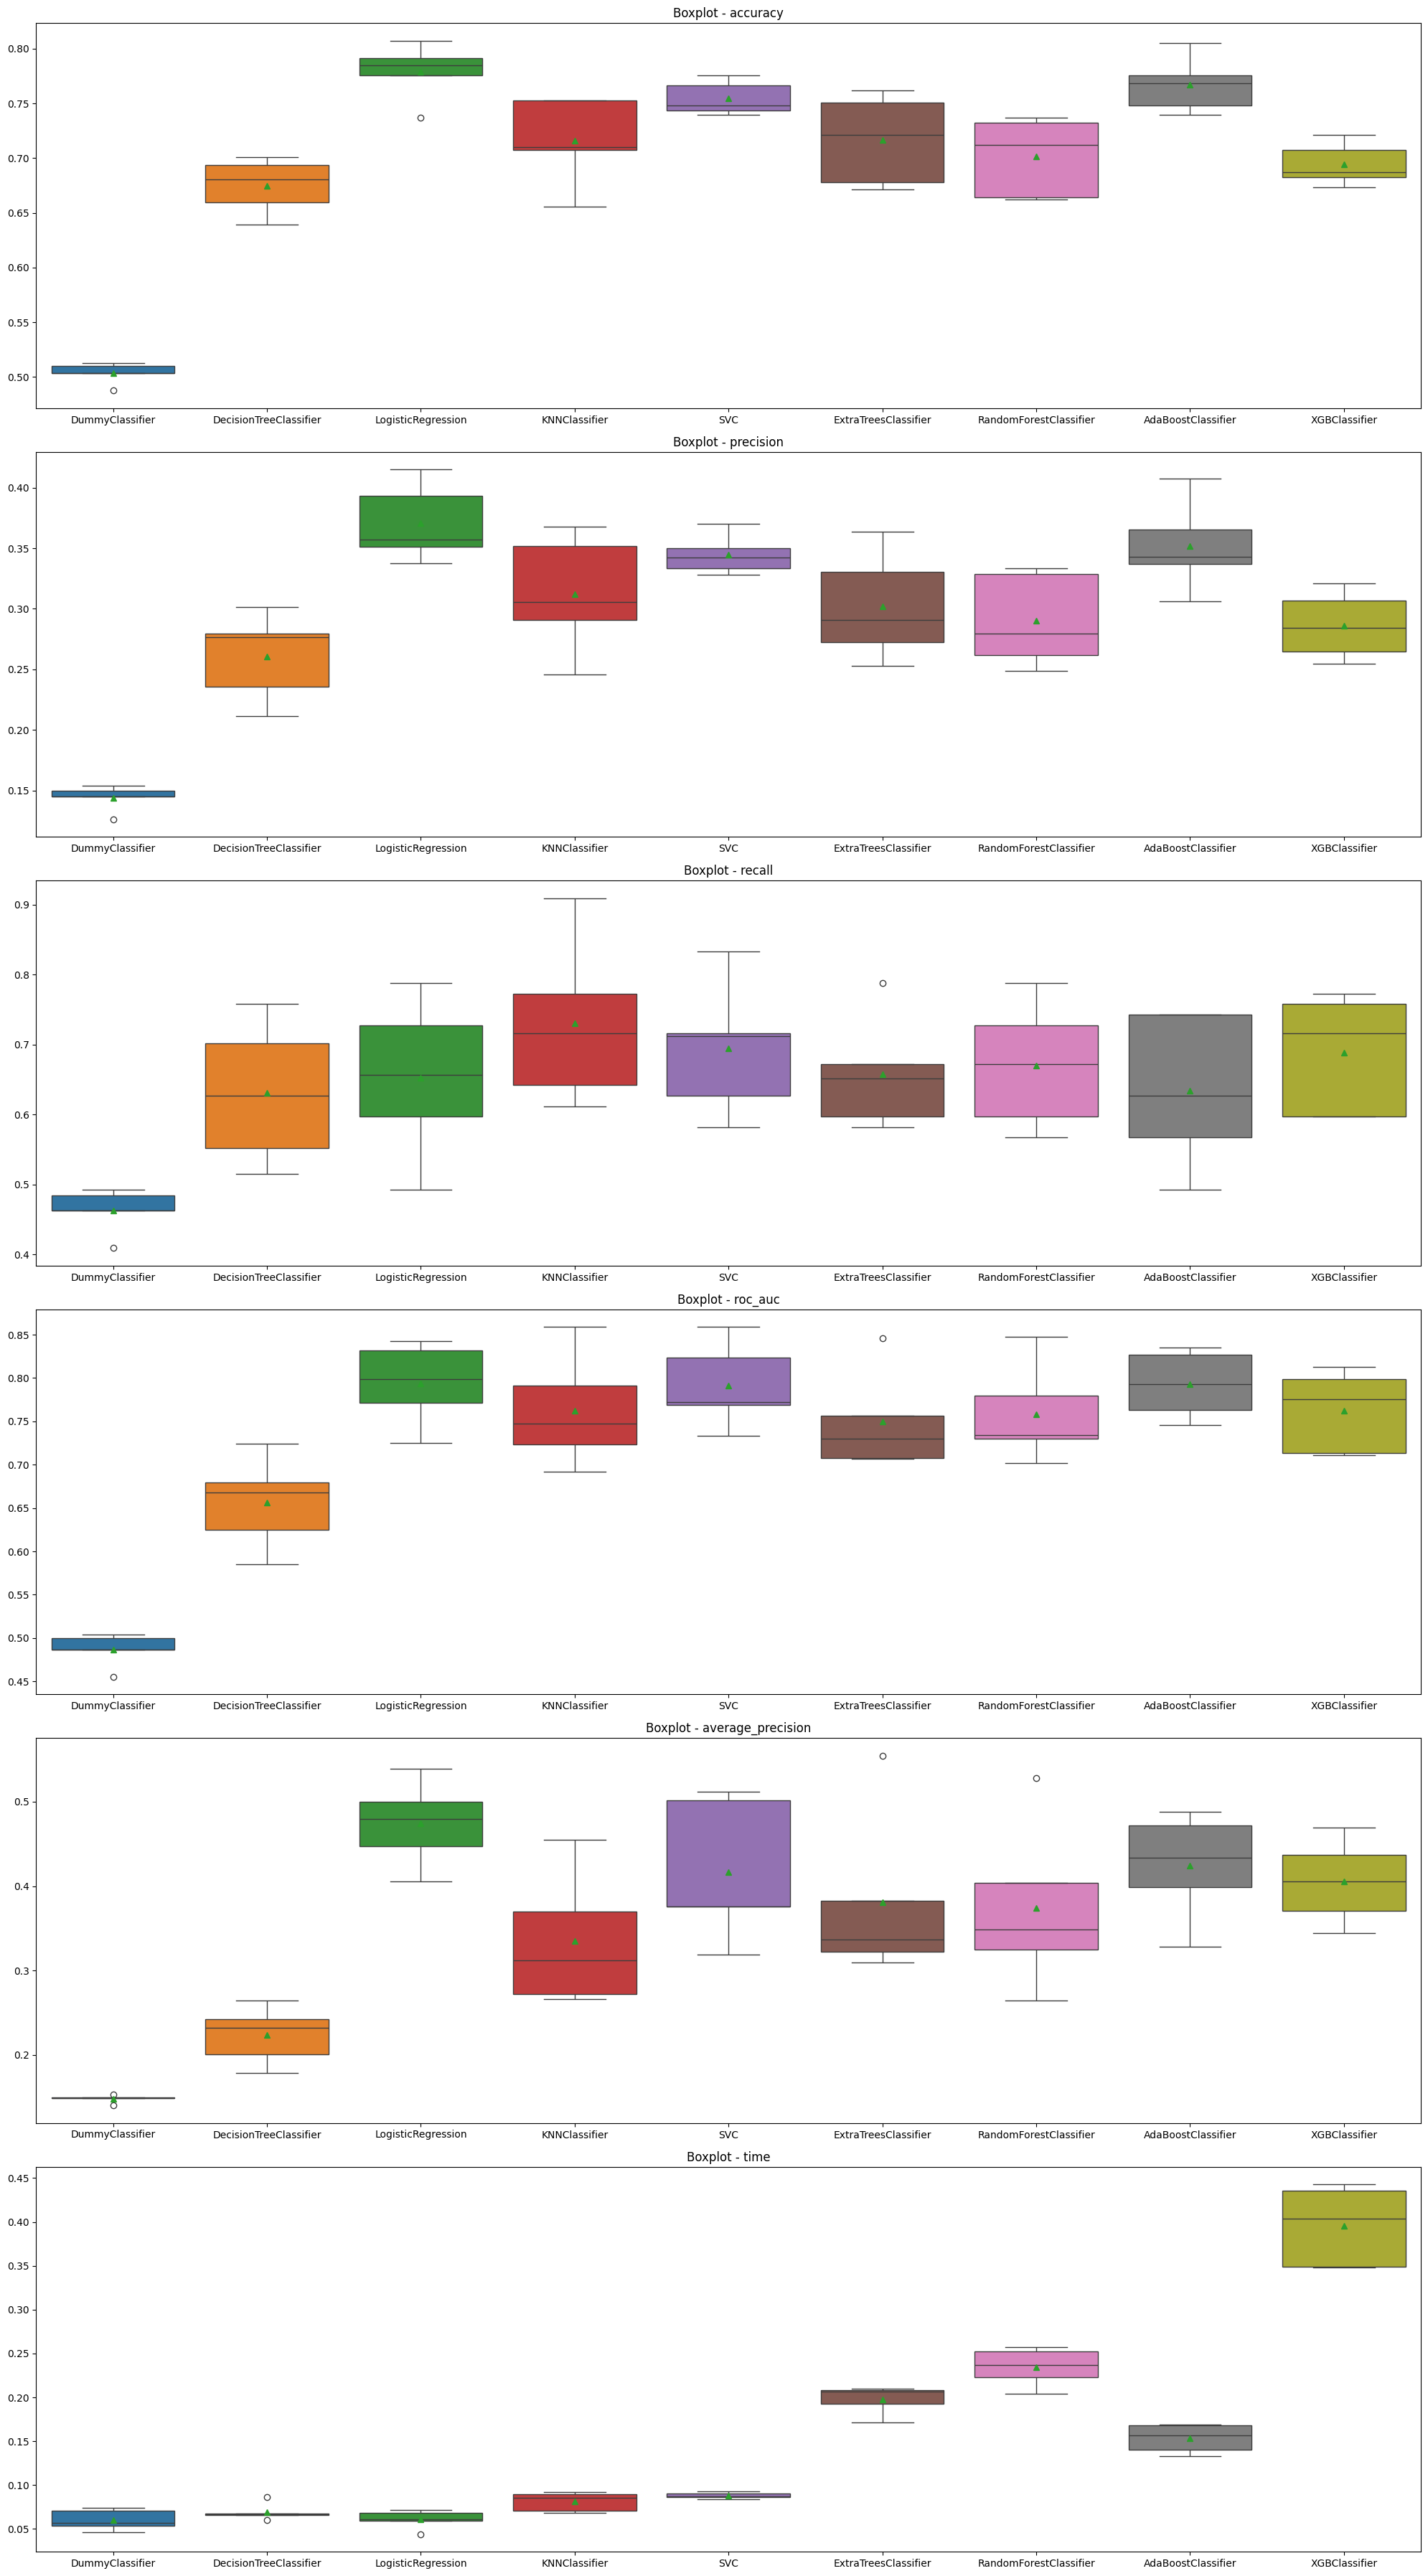

In [21]:
print('- Gráfico: Diagrama de Caixa.')

fn_charts_pandas.boxplot(df_metrics, df_metrics.columns[1:].to_list(), 'model', 'model', num_cols = 1, height_figsize = 6)

plt.savefig(f'../images/outputs/charts/pandas/nb07_boxplot_models.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 07.4.3. Comparando a performance das métricas dos modelo

|Posição|Accuracy|Precision|Recall|ROC_AUC|Average Precision|Time|
|------------|-----------------------|-----------------------|-----------------------|-----------------------|-----------------------|-----------------------|
|Referência|Quanto maior melhor|Quanto maior melhor|Quanto maior melhor| Quanto maior melhor|Quanto maior melhor|Quanto menor melhor|
|1|AdaBoostClassifier|AdaBoostClassifier|SVC|SVC|**LogisticRegression**|DecisionTreeClassifier|
|2|**LogisticRegression**|**LogisticRegression**|KNNClassifier|AdaBoostClassifier|AdaBoostClassifier|DummyClassifier|
|3|SVC|SVC|AdaBoostClassifier|**LogisticRegression**|SVC|KNNClassifier|
|4|KNNClassifier|KNNClassifier|**LogisticRegression**|RandomForestClassifier|ExtraTreesClassifier|**LogisticRegression**|
|5|ExtraTreesClassifier|ExtraTreesClassifier|RandomForestClassifier|ExtraTreesClassifier|RandomForestClassifier|SVC|
|6|RandomForestClassifier|RandomForestClassifier|ExtraTreesClassifier|KNNClassifier|XGBClassifier|AdaBoostClassifier|
|7|XGBClassifier|XGBClassifier|XGBClassifier|XGBClassifier|KNNClassifier|ExtraTreesClassifier|
|8|DecisionTreeClassifier|DecisionTreeClassifier|DecisionTreeClassifier|DecisionTreeClassifier|DecisionTreeClassifier|RandomForestClassifier|
|9|DummyClassifier|DummyClassifier|DummyClassifier|DummyClassifier|DummyClassifier|XGBClassifier|

### 07.4.4. Definindo o modelo selecionado

Após análise dos resultados de cada um dos modelos, é possível concluir que o modelo com os melhores resultados foi o de Logistic Regression, pois esteve nas primeiras posições nos resultados das métricas de Accuracy, Precision, ROC_AUC, Average Precision, apesar de ter ficado na mediana em relação ao Recall e ao Time. Além disso, no caso de datasets desbalanceados como é o caso desse estudo, as principais métricas avaliadas são o ROC_AUC e o Average Precision, onde o modelo de Logistic Regression também obteve as melhores performances combinadas. E em relação ao processamento, esse modelo também teve uma boa performance com um tempo de processamento dentro do normal.

Portando, diante de todo esse contexto, **o melhor modelo para ser usado no projeto é o Logistic Regression**. Porém é importante destacar que os modelos Ada Boost e SVC também tiveram desempenhos muito bons.

**Obs:** A tabela acima foi feita em cima de uma execução específica do notebook. A cada execução do notebook é possível que os valores das métricas variem um pouco, por isso pode ser que a tabela apresente uma ordem dos resultados levemente diferente de quando foi elaborada.